In [1]:
from modules import *
from functions import *

Set up the model

In [13]:
N = int(500)                   # Number of neurons
a = 10                         # Propensity parameter (for tanh(a*w))
x_stim = 0.5                   # POSITION to stimulate at during deprivation (in [0, L])
n_test_positions = 100         # Number of x-samples to test preferred position
L = 1.0                        # Track length (choose units: meters or bins)

rng = np.random.default_rng(0)
sigmas = rng.normal(loc=0.05*L, scale=0.015*L, size=N)
vars = np.clip(sigmas, 0.02*L, 0.10*L)

learning_rate = 1e-2

n_days = 28
n_norm_per_day = 1
n_steps_per_norm = 30
n_steps = n_steps_per_norm * n_norm_per_day * n_days
init_steps = 300 

hebb_scaling = 0.3
rand_scaling = 1.0

# --- Initialise weights with NON-WRAPPED place fields ---
W_init = initialise_W(N, vars, L=L)   # uses place_matrix_different_vars under the hood

# --- Short baseline prerun with position inputs (baseline sampling) ---
W_baseline = prerun(
    W_init, x_stim, a,
    hebb_scaling, rand_scaling, learning_rate,
    n_steps_per_norm, init_steps, L=L
)

# --- Allocate arrays (same shape) ---
W = np.zeros((N, N, n_steps + 1))
W[:, :, 0] = W_baseline
W_per_day = np.zeros((N, N, n_days))

PPs = [ get_preferred_positions(N, W_per_day[:, :, d], n_positions=n_test_positions, L=L)
        for d in range(n_days) ]

# --- Main learning loop (baseline shown; switch to 'deprivation' to clamp at x_stim) ---
for t in tqdm(range(n_steps)):
    W_old = W[:, :, t]

    # Hebbian component from position input (baseline = sample x ~ U(0, L))
    H = single_hebbian_component(N, W_old, x_stim, stim_type='baseline', L=L)

    # Random (volatility) component
    eta = np.random.randn(N, N)

    # Weight-dependent propensity
    prop_function = propensity(W_old, a)

    # Scale terms (unchanged)
    hebb = hebb_scaling * H
    rand = rand_scaling * eta

    # Update
    W_new = W_old + learning_rate * prop_function * (hebb + rand)

    # (Optional) keep weights excitatory
    # W_new = np.clip(W_new, 0, None)

    # Periodic homeostatic normalization
    if t % n_steps_per_norm == 0:
        normalisation(W_new)
        if t % (n_steps_per_norm * n_norm_per_day) == 0:
            day_idx = t // (n_steps_per_norm * n_norm_per_day)
            if day_idx < n_days:
                W_per_day[:, :, day_idx] = W_new

    W[:, :, t + 1] = W_new

100%|██████████| 840/840 [00:23<00:00, 35.21it/s]


In [14]:
print("vars min/max:", float(np.min(vars)), float(np.max(vars)))
print("L =", L)
# Inspect one column before normalization:
x = np.linspace(0, L, N)
col = stats.norm.pdf(x, loc=x[N//2], scale=vars[N//2])
print("col range:", float(col.min()), float(col.max()))


vars min/max: 0.02 0.09599055108573346
L = 1.0
col range: 3.1174288640608297e-19 7.523146076323644


Graph W_init heatmaps 

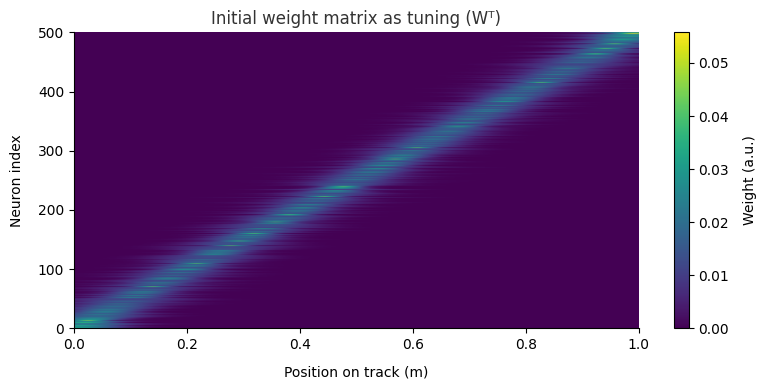

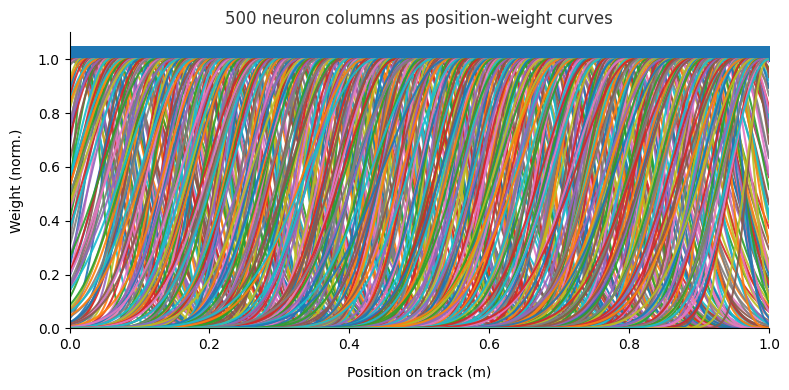

In [20]:
def plot_W_init_heatmap(W, L=1.0, title="Weight matrix as tuning (Wᵀ)"):
    """
    Show W^T as a neuron × position heatmap so the x-axis is position (m),
    y-axis is neuron index, like your previous population heatmap.
    """
    M_inputs, N_neurons = W.shape  # current code: N×N, but works for M×N too
    x = np.linspace(0.0, L, M_inputs)

    plt.figure(figsize=(8, 4))
    # transpose so rows = neurons, columns = positions
    plt.imshow(W.T, aspect='auto', origin='lower',
               extent=[x[0], x[-1], 0, N_neurons])
    plt.colorbar(label="Weight (a.u.)")
    plt.xlabel("Position on track (m)")
    plt.ylabel("Neuron index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_W_init_columns_as_curves(W, L=1.0, max_curves=20, normalize_each=True):
    """
    Plot a subset of neuron columns as curves over position (like tuning curves).
    Each curve is one column W[:, i] vs position. Optionally normalize each
    curve to its own max for readability.
    """
    M_inputs, N_neurons = W.shape
    x = np.linspace(0.0, L, M_inputs)
    k = min(max_curves, N_neurons)

    plt.figure(figsize=(8, 4))
    for i in range(k):
        y = W[:, i]
        if normalize_each and y.max() > 0:
            y = y / y.max()
        plt.plot(x, y, alpha=0.9)
    # mark approximate centers (argmax of each shown column)
    centers_idx = np.argmax(W[:, :k], axis=0)
    centers_x = x[centers_idx]
    plt.scatter(centers_x, np.ones(k)*1.02, marker='|', s=120)
    plt.ylim(0, 1.1 if normalize_each else None)
    plt.xlabel("Position on track (m)")
    plt.ylabel("Weight" + (" (norm.)" if normalize_each else " (a.u.)"))
    plt.title(f"{k} neuron columns as position-weight curves")
    plt.tight_layout()
    plt.show()

plot_W_init_heatmap(W_init, L=L, title="Initial weight matrix as tuning (Wᵀ)")
plot_W_init_columns_as_curves(W_init, L=L, max_curves=500)


## Supp. Fig. 3a

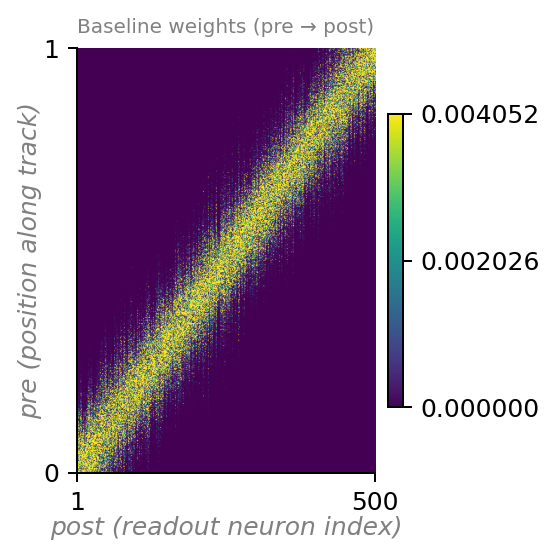

In [18]:
def supp_fig_3a(W_baseline, L=1.0, vmax=None):
    """
    Visualise the baseline feedforward weight matrix W (pre → post).
    Rows: presynaptic place-field units (sorted along the track 0..L)
    Cols: postsynaptic readout units
    Color: weight strength (after normalization)

    Args
    ----
    W_baseline : (N, N) array
        Weights after the baseline prerun / normalization.
    L : float
        Track length; used only for axis labels.
    vmax : float or None
        Max color scale. If None, it auto-scales to data.
    """
    import matplotlib.pyplot as plt
    N = W_baseline.shape[0]

    fig, ax = plt.subplots(figsize=(3.2, 3.2), dpi=180)
    im = ax.imshow(W_baseline, origin='lower', aspect='auto',
               vmin=W_baseline.min(), vmax=W_baseline.max()*0.01)

    cbar = plt.colorbar(im, ax=ax, fraction=0.045, pad=0.04)
    # show 3 evenly spaced ticks on the colorbar
    vmin = 0.0
    vmax_eff = im.norm.vmax
    cbar.ax.set_yticks([vmin, 0.5*(vmin+vmax_eff), vmax_eff])

    # Ticks at the ends of the matrices
    ax.set_yticks([0, N-1]); ax.set_xticks([0, N-1])
    # Label those ticks in *position* units on the y-axis for intuition
    ax.set_yticklabels([f"0", f"{L:g}"])
    ax.set_xticklabels([f"1", f"{N}"])

    ax.set_xlabel('post (readout neuron index)', labelpad=0.5, fontstyle='italic', c='gray')
    ax.set_ylabel('pre (position along track)', labelpad=0.5, fontstyle='italic', c='gray')

    ax.set_title("Baseline weights (pre → post)", fontsize=8, color='gray')
    plt.tight_layout()
    plt.show()

supp_fig_3a(W_baseline, L=L)

## Supp. Fig. 3c

In [ ]:
def supp_fig_3c(W):
    fig, ax = plt.subplots(figsize=(2.5, 2.5), dpi=180)
    ax2 = ax.twinx()
    x = np.linspace(0, 1, 100)
    ax.plot(x, propensity(x, 10), c='firebrick')
    ax2.hist(W[:, :, -1].flatten(), bins=103, density=False, color='gray', alpha=0.5)
    ax2.set_yscale('log')
    ax.set_xlim([0, 0.4]); ax.set_xticks([0, 0.2, 0.4])
    ax.set_ylim([0, 1.01]); ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel(r"Weight, $w$")
    ax.set_ylabel(r"$\rho(w)$", rotation=0, labelpad=20)
    ax2.set_ylabel(r"Count", rotation=270, labelpad=20, color='darkgray')
    ax2.spines['right'].set_color('darkgray'); ax2.tick_params(axis='y', colors='darkgray')
    sns.despine(right=False)
    fig.show()


## Supp. Fig. 3b

In [ ]:
def supp_fig_3b():
    N=100000
    vars = np.random.lognormal(2, 0.6, N)
    fig, ax = plt.subplots(figsize=(2.3, 2.3), dpi=180)
    ax.hist(vars, bins=100, density=True, histtype='step', lw=1, color='k')
    ax.hist(vars, bins=100, density=True, histtype='stepfilled', color='firebrick')
    ax.set_yticks([0, 0.1]); ax.set_xlim(-4, 100)
    ax.set_xlabel(r'Tuning curve width $ \; [\degree]$')
    ax.set_ylabel('Frequency')
    fig.show()

## Fig. 3b

In [ ]:
def fig_3b():
    x = np.linspace(0, 0.2)
    y = propensity(x, a=20)
    fig, ax = plt.subplots(1, 1, figsize=(1.2, 1.2), dpi=140)
    ax.plot(x, y, c='k', lw=1.5)
    ax.set_xlabel(r'w', labelpad=5)
    ax.set_ylabel(r'$\rho(w)$', labelpad=1)
    ax.set_ylim(0, 1.01); ax.set_xlim(0, 0.2); ax.set_xticks([]); ax.set_yticks([0, 1])
    fig.show()